# 🌆 Urban Expansion Prediction Using Multi-Source Satellite Data
## Predicting Urban Growth Across Asia by 2030

**Author:** Sagarika Raju | USC MS Analytics

### Project Structure
1. Data Loading & Visualization
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Architecture & Training
5. Results & Evaluation
6. Urban Risk Mapping

**Data Sources:** NASA SEDAC · NASA GPW v4 · NOAA VIIRS · NASA SRTM · NASA MODIS

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import from_bounds
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print(f"  rasterio version: {rasterio.__version__}")
print(f"  numpy version: {np.__version__}")

Libraries loaded successfully
  rasterio version: 1.5.0
  numpy version: 2.4.4


In [2]:
# File paths
data_dir = '../data/raw'

files = {
    'urban': f'{data_dir}/global-grid-prob-urban-expansion-2030-wgs84.tif',
    'population': f'{data_dir}/population_density.tif',
    'lights': f'{data_dir}/nighttime_lights.tif',
    'elevation': f'{data_dir}/elevation.tif',
    'ndvi': f'{data_dir}/ndvi.tif'
}

# Asia bounding box
asia_bounds = {
    'lon_min': 25.0, 'lon_max': 180.0,
    'lat_min': 1.0,  'lat_max': 81.0
}

def load_and_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(
            bounds['lon_min'], bounds['lat_min'],
            bounds['lon_max'], bounds['lat_max'],
            transform=src.transform
        )
        data = src.read(1, window=window).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
    return data

# Load all layers
urban = load_and_crop(files['urban'], asia_bounds)
pop   = load_and_crop(files['population'], asia_bounds)
lights= load_and_crop(files['lights'], asia_bounds)
elev  = load_and_crop(files['elevation'], asia_bounds)
ndvi  = load_and_crop(files['ndvi'], asia_bounds)

print("✅ All layers loaded successfully")
print(f"\n{'Layer':<15} {'Shape':<20} {'Min':>8} {'Max':>10} {'NaN%':>8}")
print("-" * 65)
for name, data in [('Urban', urban), ('Population', pop), 
                    ('Lights', lights), ('Elevation', elev), ('NDVI', ndvi)]:
    print(f"{name:<15} {str(data.shape):<20} {np.nanmin(data):>8.2f} "
          f"{np.nanmax(data):>10.2f} {np.isnan(data).mean()*100:>7.1f}%")

✅ All layers loaded successfully

Layer           Shape                     Min        Max     NaN%
-----------------------------------------------------------------
Urban           (1662, 3221)             0.00     101.00    47.9%
Population      (891, 1725)          -340282306073709652508363335590014353408.00   58508.08     0.0%
Lights          (891, 1725)              0.00    1447.95     0.0%
Elevation       (891, 1725)          -32767.00    6726.00     0.0%
NDVI            (891, 1725)          -1914.00    9939.00     0.0%


In [3]:
def clean_layer(data, valid_min, valid_max):
    """Replace out-of-range values with nan"""
    data = data.copy()
    data[data < valid_min] = np.nan
    data[data > valid_max] = np.nan
    return data

# Clean with known valid ranges
urban = clean_layer(urban,     0,      100)
pop   = clean_layer(pop,       0,    50000)
lights= clean_layer(lights,    0,     1500)
elev  = clean_layer(elev,      0,     8849)
ndvi  = clean_layer(ndvi,   -200,    10000)

print("✅ Data cleaned")
print(f"\n{'Layer':<15} {'Min':>8} {'Max':>10} {'Mean':>10} {'NaN%':>8}")
print("-" * 55)
for name, data in [('Urban', urban), ('Population', pop),
                    ('Lights', lights), ('Elevation', elev), ('NDVI', ndvi)]:
    print(f"{name:<15} {np.nanmin(data):>8.2f} {np.nanmax(data):>10.2f} "
          f"{np.nanmean(data):>10.2f} {np.isnan(data).mean()*100:>7.1f}%")

✅ Data cleaned

Layer                Min        Max       Mean     NaN%
-------------------------------------------------------
Urban               0.00     100.00       1.30    48.2%
Population          0.00   48410.63      77.15    46.6%
Lights              0.00    1447.95       0.49     0.0%
Elevation           0.00    6726.00     469.32    29.7%
NDVI             -200.00    9939.00    1844.07     0.5%


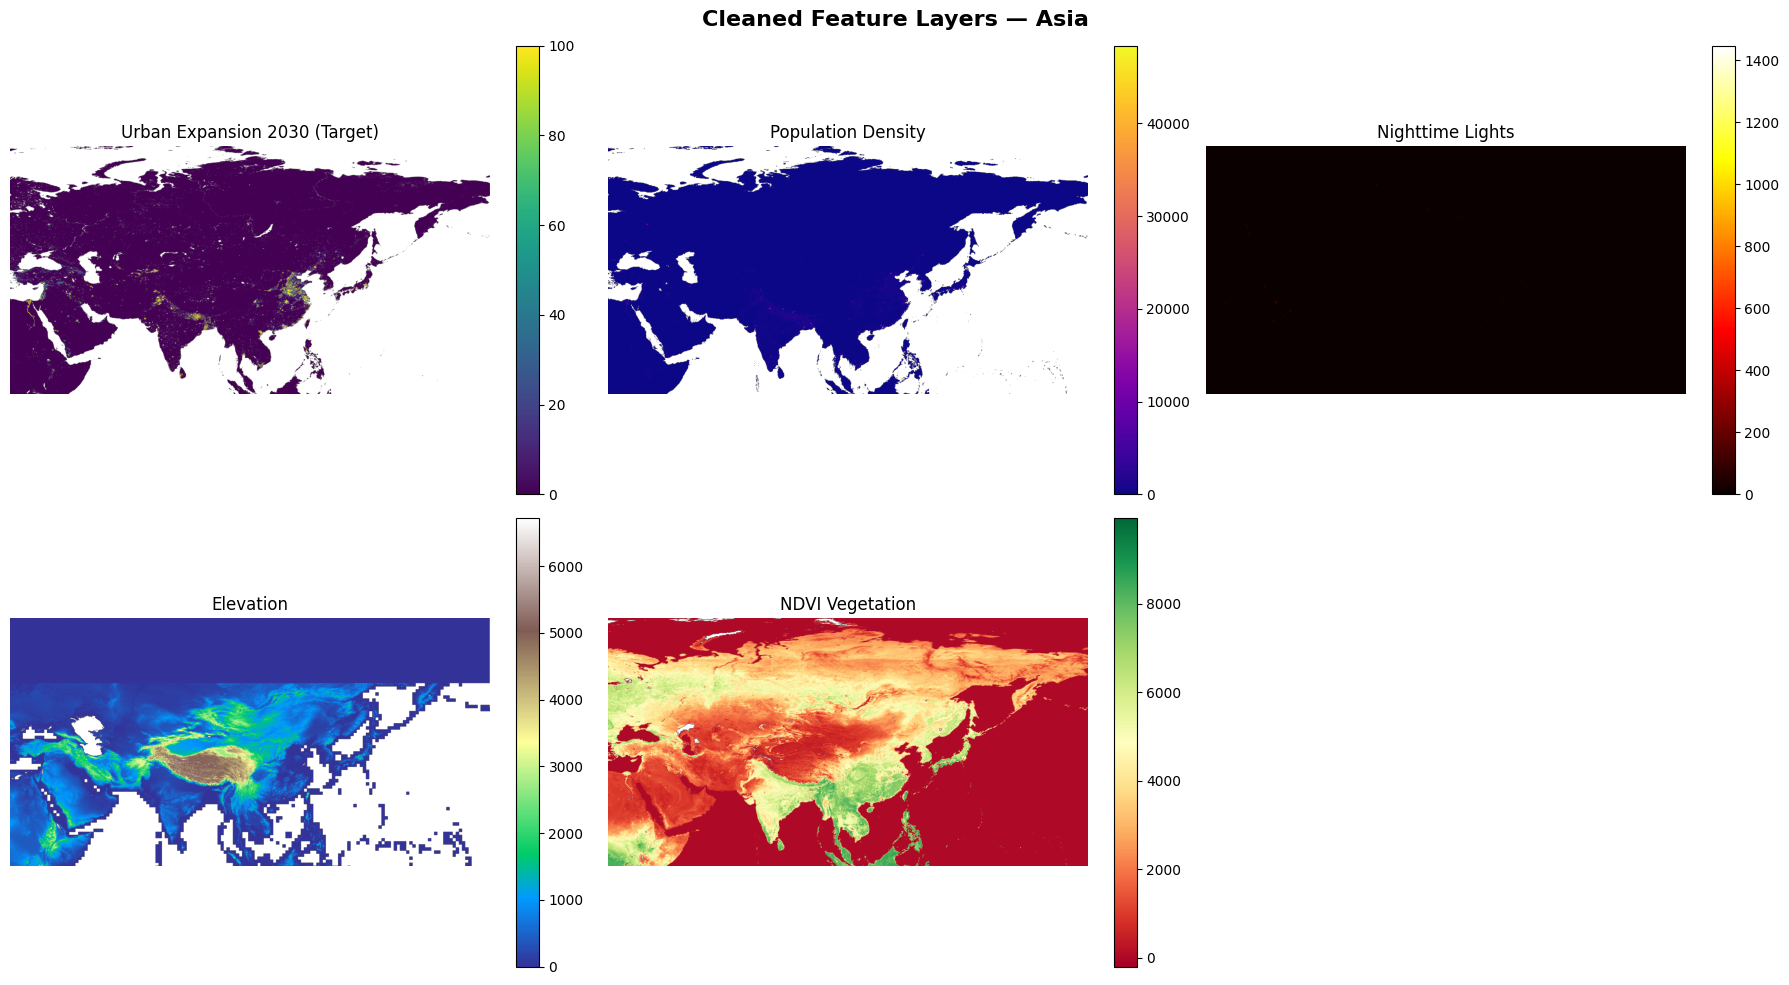

✅ Figure saved: outputs/figures/01_cleaned_layers.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

datasets = [
    (urban,  'Urban Expansion 2030 (Target)', 'viridis'),
    (pop,    'Population Density',             'plasma'),
    (lights, 'Nighttime Lights',               'hot'),
    (elev,   'Elevation',                      'terrain'),
    (ndvi,   'NDVI Vegetation',                'RdYlGn'),
]

for idx, (data, name, cmap) in enumerate(datasets):
    im = axes[idx].imshow(data, cmap=cmap)
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

axes[5].axis('off')
plt.suptitle('Cleaned Feature Layers — Asia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_cleaned_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: outputs/figures/01_cleaned_layers.png")

## 🔍 Exploratory Data Analysis (EDA)

Before building any model, we analyze the data to understand:
1. Value distributions for each feature
2. Class balance of the target variable (urban vs non-urban)
3. Correlation between features and urban expansion
4. Geographic patterns

These findings will directly inform our modeling decisions.

In [5]:
print("=" * 55)
print("EDA — TARGET VARIABLE: Urban Expansion Probability")
print("=" * 55)

# Remove NaN for analysis
urban_clean = urban[~np.isnan(urban)]

print(f"\nTotal land pixels:        {len(urban_clean):,}")
print(f"Mean urbanization prob:   {urban_clean.mean():.2f}%")
print(f"Median urbanization prob: {np.median(urban_clean):.2f}%")

# Binary classification threshold at 50%
urban_binary = (urban_clean > 50).astype(int)
n_urban = urban_binary.sum()
n_nonurban = len(urban_binary) - n_urban

print(f"\n--- Binary Classification (threshold=50%) ---")
print(f"Urban pixels:     {n_urban:,} ({n_urban/len(urban_binary)*100:.2f}%)")
print(f"Non-urban pixels: {n_nonurban:,} ({n_nonurban/len(urban_binary)*100:.2f}%)")
print(f"Class ratio:      1 : {n_nonurban/max(n_urban,1):.0f}")
print(f"\n⚠️  FINDING: Severe class imbalance detected!")
print(f"    Non-urban pixels outnumber urban pixels by {n_nonurban/max(n_urban,1):.0f}x")
print(f"    A naive model predicting all non-urban gets {n_nonurban/len(urban_binary)*100:.1f}% accuracy")
print(f"    → Model must use weighted loss to handle this")

# Distribution buckets
print(f"\n--- Probability Distribution ---")
buckets = [(0,10), (10,25), (25,50), (50,75), (75,100)]
for low, high in buckets:
    count = ((urban_clean >= low) & (urban_clean < high)).sum()
    pct = count/len(urban_clean)*100
    bar = '█' * int(pct)
    print(f"  {low:3d}-{high:3d}%: {count:8,} pixels ({pct:5.1f}%) {bar}")

EDA — TARGET VARIABLE: Urban Expansion Probability

Total land pixels:        2,774,969
Mean urbanization prob:   1.30%
Median urbanization prob: 0.00%

--- Binary Classification (threshold=50%) ---
Urban pixels:     30,050 (1.08%)
Non-urban pixels: 2,744,919 (98.92%)
Class ratio:      1 : 91

⚠️  FINDING: Severe class imbalance detected!
    Non-urban pixels outnumber urban pixels by 91x
    A naive model predicting all non-urban gets 98.9% accuracy
    → Model must use weighted loss to handle this

--- Probability Distribution ---
    0- 10%: 2,720,056 pixels ( 98.0%) ██████████████████████████████████████████████████████████████████████████████████████████████████
   10- 25%:   18,845 pixels (  0.7%) 
   25- 50%:    5,793 pixels (  0.2%) 
   50- 75%:    5,394 pixels (  0.2%) 
   75-100%:   11,389 pixels (  0.4%) 


In [6]:
print("=" * 55)
print("EDA — FEATURE DISTRIBUTIONS")
print("=" * 55)

features = {
    'Population Density': pop,
    'Nighttime Lights': lights,
    'Elevation': elev,
    'NDVI': ndvi
}

for name, data in features.items():
    clean = data[~np.isnan(data)]
    zeros_pct = (clean == 0).mean() * 100
    print(f"\n{name}:")
    print(f"  Mean:    {clean.mean():>10.2f}")
    print(f"  Median:  {np.median(clean):>10.2f}")
    print(f"  Std:     {clean.std():>10.2f}")
    print(f"  Zero pixels: {zeros_pct:.1f}%")
    print(f"  p25:     {np.percentile(clean, 25):>10.2f}")
    print(f"  p75:     {np.percentile(clean, 75):>10.2f}")
    print(f"  p95:     {np.percentile(clean, 95):>10.2f}")
    print(f"  p99:     {np.percentile(clean, 99):>10.2f}")

EDA — FEATURE DISTRIBUTIONS

Population Density:
  Mean:         77.15
  Median:        2.57
  Std:         492.30
  Zero pixels: 4.0%
  p25:           0.17
  p75:          23.42
  p95:         344.80
  p99:        1175.14

Nighttime Lights:
  Mean:          0.49
  Median:        0.29
  Std:           3.70
  Zero pixels: 7.5%
  p25:           0.22
  p75:           0.45
  p95:           0.90
  p99:           3.27

Elevation:
  Mean:        469.32
  Median:       54.00
  Std:         921.84
  Zero pixels: 46.0%
  p25:           0.00
  p75:         534.00
  p95:        2175.00
  p99:        4901.00

NDVI:
  Mean:       1844.07
  Median:      872.50
  Std:        2219.12
  Zero pixels: 46.2%
  p25:           0.00
  p75:        3377.50
  p95:        6218.23
  p99:        7887.92


In [7]:
print("=" * 55)
print("EDA — FEATURE CORRELATION WITH URBAN EXPANSION")
print("=" * 55)

# Resize all to match urban shape for correlation analysis
target_shape = urban.shape

def resize_layer(data, shape):
    data_clean = np.where(np.isnan(data), 0, data)
    return resize(data_clean, shape, anti_aliasing=True)

pop_r   = resize_layer(pop,    target_shape)
lights_r= resize_layer(lights, target_shape)
elev_r  = resize_layer(elev,   target_shape)
ndvi_r  = resize_layer(ndvi,   target_shape)

# Only use non-NaN urban pixels for correlation
mask = ~np.isnan(urban)
urban_flat = urban[mask]

for name, feat in [('Population Density', pop_r),
                   ('Nighttime Lights',   lights_r),
                   ('Elevation',          elev_r),
                   ('NDVI',               ndvi_r)]:
    feat_flat = feat[mask]
    corr = np.corrcoef(urban_flat, feat_flat)[0, 1]
    direction = "📈 positive" if corr > 0 else "📉 negative"
    strength = "strong" if abs(corr) > 0.3 else "moderate" if abs(corr) > 0.1 else "weak"
    print(f"\n{name}:")
    print(f"  Correlation with urban: {corr:+.4f} ({strength} {direction})")

print("\n--- Urban vs Non-Urban Feature Means ---")
urban_mask = (urban > 50) & ~np.isnan(urban)
nonurban_mask = (urban <= 50) & ~np.isnan(urban)

print(f"\n{'Feature':<20} {'Urban Mean':>12} {'NonUrban Mean':>14} {'Ratio':>8}")
print("-" * 58)
for name, feat in [('Population', pop_r), ('Lights', lights_r),
                   ('Elevation', elev_r), ('NDVI', ndvi_r)]:
    u_mean = feat[urban_mask].mean()
    n_mean = feat[nonurban_mask].mean()
    ratio = u_mean / max(n_mean, 0.0001)
    print(f"{name:<20} {u_mean:>12.3f} {n_mean:>14.3f} {ratio:>8.2f}x")

EDA — FEATURE CORRELATION WITH URBAN EXPANSION

Population Density:
  Correlation with urban: +0.4440 (strong 📈 positive)

Nighttime Lights:
  Correlation with urban: +0.1515 (moderate 📈 positive)

Elevation:
  Correlation with urban: -0.0464 (weak 📉 negative)

NDVI:
  Correlation with urban: +0.0815 (weak 📈 positive)

--- Urban vs Non-Urban Feature Means ---

Feature                Urban Mean  NonUrban Mean    Ratio
----------------------------------------------------------
Population               1213.758         53.119    22.85x
Lights                      5.501          0.615     8.95x
Elevation                 246.925        634.121     0.39x
NDVI                     4566.179       3413.523     1.34x


## 📊 EDA Summary & Modeling Decisions

### Key Findings:

| Finding | Implication |
|---|---|
| **91:1 class imbalance** | Use weighted loss (weight=50x for urban pixels) |
| **Population strongest predictor (r=0.44, 22x ratio)** | Most important feature |
| **Nighttime lights 8.95x higher in cities** | Needs log scaling due to extreme skew |
| **Cities on lower elevation (0.39x ratio)** | Inverse relationship, keep as feature |
| **All features right-skewed** | Apply log normalization to population & lights |

### Decisions Made Based on EDA:
1. **Weighted binary crossentropy loss** — penalize missing urban pixels 50x
2. **Log normalization** for population and nighttime lights
3. **Min-max normalization** for elevation and NDVI
4. **Keep all 4 features** — each adds unique signal
5. **Threshold tuning** — use 0.3 instead of 0.5 for predictions given imbalance

In [8]:
print("=" * 55)
print("PREPROCESSING — Based on EDA Findings")
print("=" * 55)

def normalize_log(data):
    """Log normalize — for right-skewed features (pop, lights)"""
    data = np.where(np.isnan(data), 0, data)
    data = np.log1p(data)
    data = (data - data.min()) / (data.max() - data.min() + 1e-8)
    return data

def normalize_minmax(data):
    """Min-max normalize — for elevation and NDVI"""
    data = np.where(np.isnan(data), 0, data)
    data = (data - data.min()) / (data.max() - data.min() + 1e-8)
    return data

# Target
urban_norm = normalize_minmax(urban)

# Features — method chosen based on EDA
target_shape = urban.shape
pop_norm    = normalize_log(resize_layer(pop,    target_shape))
lights_norm = normalize_log(resize_layer(lights, target_shape))
elev_norm   = normalize_minmax(resize_layer(elev, target_shape))
ndvi_norm   = normalize_minmax(resize_layer(ndvi, target_shape))

print("\nNormalization applied:")
print("  Population Density → log normalization (skew=high, EDA finding)")
print("  Nighttime Lights   → log normalization (skew=high, EDA finding)")
print("  Elevation          → min-max normalization")
print("  NDVI               → min-max normalization")

print(f"\n{'Layer':<20} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 48)
for name, data in [('Urban (target)', urban_norm),
                   ('Population',     pop_norm),
                   ('Lights',         lights_norm),
                   ('Elevation',      elev_norm),
                   ('NDVI',           ndvi_norm)]:
    print(f"{name:<20} {data.min():>8.4f} {data.max():>8.4f} {data.mean():>8.4f}")

PREPROCESSING — Based on EDA Findings

Normalization applied:
  Population Density → log normalization (skew=high, EDA finding)
  Nighttime Lights   → log normalization (skew=high, EDA finding)
  Elevation          → min-max normalization
  NDVI               → min-max normalization

Layer                     Min      Max     Mean
------------------------------------------------
Urban (target)         0.0000   1.0000   0.0067
Population             0.0000   1.0000   0.0984
Lights                 0.0000   1.0000   0.0455
Elevation              0.0000   1.0000   0.0493
NDVI                   0.0000   1.0000   0.2024


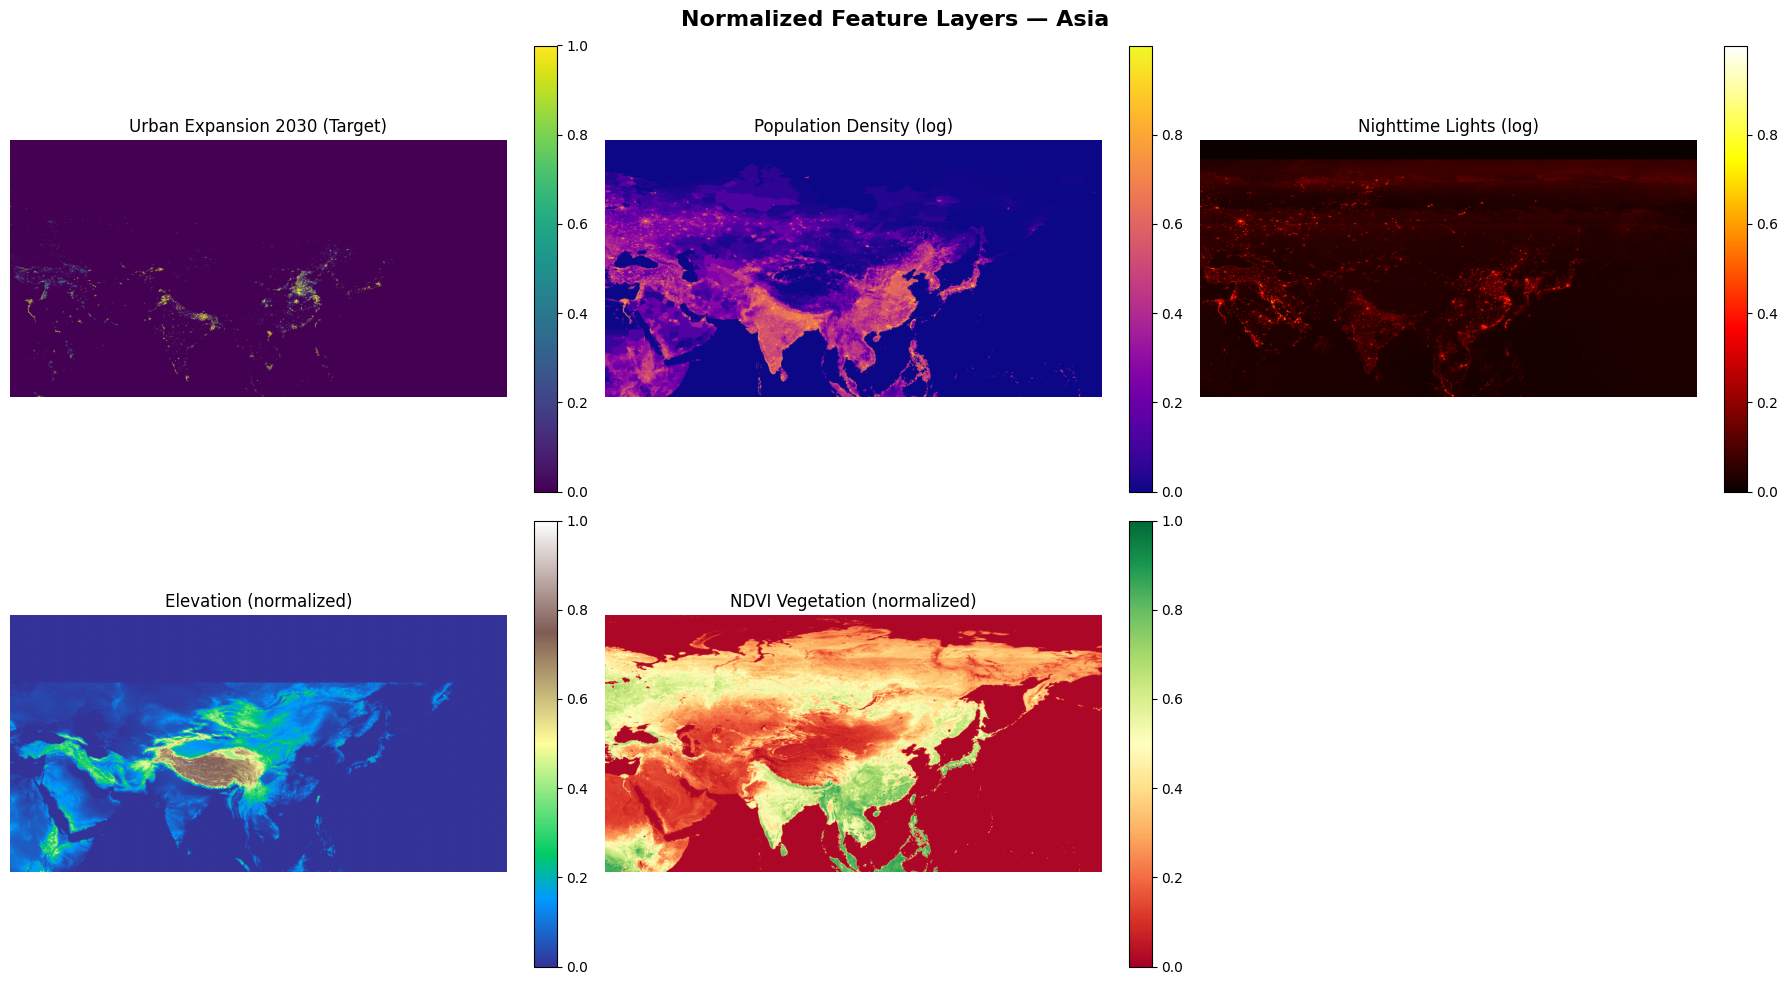

✅ Figure saved: outputs/figures/02_normalized_layers.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

datasets = [
    (urban_norm,  'Urban Expansion 2030 (Target)', 'viridis'),
    (pop_norm,    'Population Density (log)',       'plasma'),
    (lights_norm, 'Nighttime Lights (log)',         'hot'),
    (elev_norm,   'Elevation (normalized)',         'terrain'),
    (ndvi_norm,   'NDVI Vegetation (normalized)',   'RdYlGn'),
]

for idx, (data, name, cmap) in enumerate(datasets):
    im = axes[idx].imshow(data, cmap=cmap)
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

axes[5].axis('off')
plt.suptitle('Normalized Feature Layers — Asia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_normalized_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: outputs/figures/02_normalized_layers.png")

In [10]:
print("=" * 55)
print("PATCH CREATION")
print("=" * 55)

TILE_SIZE = 128

# Stack 4 input features
feature_stack = np.stack([pop_norm, lights_norm, elev_norm, ndvi_norm], axis=-1)
print(f"\nFeature stack shape: {feature_stack.shape}  (H, W, 4 features)")
print(f"Target shape:        {urban_norm.shape}")

def create_patches(features, target, tile_size):
    X, y = [], []
    h, w = target.shape
    for i in range(0, h - tile_size, tile_size):
        for j in range(0, w - tile_size, tile_size):
            feat_patch = features[i:i+tile_size, j:j+tile_size, :]
            targ_patch = target[i:i+tile_size, j:j+tile_size]
            if feat_patch.shape == (tile_size, tile_size, 4):
                X.append(feat_patch)
                y.append(targ_patch)
    return np.array(X), np.array(y)

X, y = create_patches(feature_stack, urban_norm, TILE_SIZE)
y = y[..., np.newaxis]

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTotal patches:     {len(X)}")
print(f"Training patches:  {len(X_train)}")
print(f"Validation patches:{len(X_val)}")
print(f"\nX shape: {X.shape}  (patches, height, width, features)")
print(f"y shape: {y.shape}  (patches, height, width, 1)")

# Verify class imbalance in patches
urban_pct = (y_train > 0.5).mean() * 100
print(f"\nClass distribution in training patches:")
print(f"  Urban pixels:     {urban_pct:.2f}%")
print(f"  Non-urban pixels: {100-urban_pct:.2f}%")
print(f"  ⚠️  Confirms EDA finding — weighted loss required")

PATCH CREATION

Feature stack shape: (1662, 3221, 4)  (H, W, 4 features)
Target shape:        (1662, 3221)

Total patches:     300
Training patches:  240
Validation patches:60

X shape: (300, 128, 128, 4)  (patches, height, width, features)
y shape: (300, 128, 128, 1)  (patches, height, width, 1)

Class distribution in training patches:
  Urban pixels:     0.58%
  Non-urban pixels: 99.42%
  ⚠️  Confirms EDA finding — weighted loss required


## 🧠 Model Architecture — U-Net

### Why U-Net?
- Designed for spatial segmentation tasks
- Skip connections preserve fine geographic detail
- Proven in remote sensing and medical imaging
- Handles imbalanced spatial data well

### Key Design Decisions (from EDA):
| Decision | Reason |
|---|---|
| **4-channel input** | One channel per feature (pop, lights, elev, ndvi) |
| **Weighted loss (50x)** | 91:1 class imbalance found in EDA |
| **BatchNormalization** | Stabilizes training with skewed input distributions |
| **Dropout(0.3)** | Prevents overfitting on small dataset (300 patches) |
| **Sigmoid output** | Predict probability 0-1 (regression, not hard classification) |

In [ ]:
 
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
    UpSampling2D, concatenate, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

# Weighted loss — directly addresses EDA class imbalance finding
def weighted_bce(y_true, y_pred):
    weight_positive = 50.0
    bce = K.binary_crossentropy(y_true, y_pred)
    weight_map = y_true * weight_positive + (1 - y_true)
    return K.mean(weight_map * bce)

def unet_model(input_size=(128, 128, 4)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b = Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = Dropout(0.3)(b)
    b = Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = UpSampling2D()(b)
    u1 = concatenate([u1, c3])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c2])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    u3 = UpSampling2D()(c5)
    u3 = concatenate([u3, c1])
    c6 = Conv2D(32, 3, activation='relu', padding='same')(u3)
    c6 = Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = Conv2D(1, 1, activation='sigmoid')(c6)
    return Model(inputs, outputs)

model = unet_model()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=weighted_bce,
    metrics=['accuracy', 'mae']
)

total_params = model.count_params()
print("✅ Model built successfully")
print(f"   Total parameters: {total_params:,}")
print(f"   Input shape:  (128, 128, 4)")
print(f"   Output shape: (128, 128, 1)")
print(f"   Loss function: Weighted BCE (urban weight=50x)")
print(f"   Optimizer: Adam (lr=1e-4)")

✅ Model built successfully
   Total parameters: 1,948,065
   Input shape:  (128, 128, 4)
   Output shape: (128, 128, 1)
   Loss function: Weighted BCE (urban weight=50x)
   Optimizer: Adam (lr=1e-4)


In [12]:
print("=" * 55)
print("MODEL TRAINING")
print("=" * 55)
print(f"\nTraining samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size:         16")
print(f"Max epochs:         30")
print(f"Early stopping:     patience=5\n")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '../models/best_unet_weighted.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping, checkpoint]
)

print("\n✅ Training complete!")
print(f"   Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"   Best epoch:    {history.history['val_loss'].index(min(history.history['val_loss']))+1}")
print(f"   Total epochs:  {len(history.history['loss'])}")

MODEL TRAINING

Training samples:   240
Validation samples: 60
Batch size:         16
Max epochs:         30
Early stopping:     patience=5

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8949 - loss: 0.7042 - mae: 0.3239
Epoch 1: val_loss improved from None to 0.82380, saving model to ../models/best_unet_weighted.keras

Epoch 1: finished saving model to ../models/best_unet_weighted.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9431 - loss: 0.5790 - mae: 0.2166 - val_accuracy: 0.9611 - val_loss: 0.8238 - val_mae: 0.3901
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9262 - loss: 0.4337 - mae: 0.0671
Epoch 2: val_loss improved from 0.82380 to 0.73440, saving model to ../models/best_unet_weighted.keras

Epoch 2: finished saving model to ../models/best_unet_weighted.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9340 - loss: 0.3317 - mae: 0.0644 - val_accuracy: 0.9611 - val_loss: 0.7344 - val_mae: 0.1746
Epoch 3/30
15/15 ━━━━━━━━━━━

In [13]:
print("=" * 55)
print("MODEL EVALUATION")
print("=" * 55)

y_pred = model.predict(X_val, verbose=0)

print(f"\nPrediction value range:")
print(f"  Min:  {y_pred.min():.4f}")
print(f"  Max:  {y_pred.max():.4f}")
print(f"  Mean: {y_pred.mean():.4f}")

print(f"\nPredicted urban pixels at different thresholds:")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pct = (y_pred > thresh).mean() * 100
    print(f"  threshold={thresh}: {pct:.3f}% urban predicted")

print(f"\nActual urban pixels in val set: {(y_val > 0.5).mean()*100:.3f}%")

# Find best threshold
best_f1 = 0
best_thresh = 0
y_true_flat = (y_val.flatten() > 0.5).astype(int)

print(f"\n{'Threshold':<12} {'F1':>8} {'IoU':>8} {'Precision':>12} {'Recall':>10}")
print("-" * 55)
for thresh in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    y_pred_flat = (y_pred.flatten() > thresh).astype(int)
    if y_pred_flat.sum() > 0:
        f1  = f1_score(y_true_flat, y_pred_flat, zero_division=0)
        iou = jaccard_score(y_true_flat, y_pred_flat, zero_division=0)
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
        rec  = recall_score(y_true_flat, y_pred_flat, zero_division=0)
        print(f"  {thresh:<10} {f1:>8.4f} {iou:>8.4f} {prec:>12.4f} {rec:>10.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

print(f"\n✅ Best threshold: {best_thresh} with F1={best_f1:.4f}")

MODEL EVALUATION

Prediction value range:
  Min:  0.1146
  Max:  0.4880
  Mean: 0.1725

Predicted urban pixels at different thresholds:
  threshold=0.1: 100.000% urban predicted
  threshold=0.2: 21.841% urban predicted
  threshold=0.3: 8.846% urban predicted
  threshold=0.4: 2.246% urban predicted
  threshold=0.5: 0.000% urban predicted

Actual urban pixels in val set: 0.680%

Threshold          F1      IoU    Precision     Recall
-------------------------------------------------------
  0.05         0.0135   0.0068       0.0068     1.0000
  0.1          0.0135   0.0068       0.0068     1.0000
  0.15         0.0285   0.0144       0.0145     0.9380
  0.2          0.0181   0.0091       0.0093     0.2994
  0.25         0.0167   0.0084       0.0088     0.1778
  0.3          0.0160   0.0081       0.0086     0.1120
  0.4          0.0146   0.0074       0.0095     0.0314

✅ Best threshold: 0.15 with F1=0.0285


In [14]:
print("=" * 55)
print("MODEL EVALUATION")
print("=" * 55)

y_pred = model.predict(X_val, verbose=0)

print(f"\nPrediction value range:")
print(f"  Min:  {y_pred.min():.4f}")
print(f"  Max:  {y_pred.max():.4f}")
print(f"  Mean: {y_pred.mean():.4f}")

print(f"\nPredicted urban pixels at different thresholds:")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pct = (y_pred > thresh).mean() * 100
    print(f"  threshold={thresh}: {pct:.3f}% urban predicted")

print(f"\nActual urban pixels in val set: {(y_val > 0.5).mean()*100:.3f}%")

# Find best threshold
best_f1 = 0
best_thresh = 0
y_true_flat = (y_val.flatten() > 0.5).astype(int)

print(f"\n{'Threshold':<12} {'F1':>8} {'IoU':>8} {'Precision':>12} {'Recall':>10}")
print("-" * 55)
for thresh in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    y_pred_flat = (y_pred.flatten() > thresh).astype(int)
    if y_pred_flat.sum() > 0:
        f1  = f1_score(y_true_flat, y_pred_flat, zero_division=0)
        iou = jaccard_score(y_true_flat, y_pred_flat, zero_division=0)
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
        rec  = recall_score(y_true_flat, y_pred_flat, zero_division=0)
        print(f"  {thresh:<10} {f1:>8.4f} {iou:>8.4f} {prec:>12.4f} {rec:>10.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

print(f"\n✅ Best threshold: {best_thresh} with F1={best_f1:.4f}")

MODEL EVALUATION

Prediction value range:
  Min:  0.1146
  Max:  0.4880
  Mean: 0.1725

Predicted urban pixels at different thresholds:
  threshold=0.1: 100.000% urban predicted
  threshold=0.2: 21.841% urban predicted
  threshold=0.3: 8.846% urban predicted
  threshold=0.4: 2.246% urban predicted
  threshold=0.5: 0.000% urban predicted

Actual urban pixels in val set: 0.680%

Threshold          F1      IoU    Precision     Recall
-------------------------------------------------------
  0.05         0.0135   0.0068       0.0068     1.0000
  0.1          0.0135   0.0068       0.0068     1.0000
  0.15         0.0285   0.0144       0.0145     0.9380
  0.2          0.0181   0.0091       0.0093     0.2994
  0.25         0.0167   0.0084       0.0088     0.1778
  0.3          0.0160   0.0081       0.0086     0.1120
  0.4          0.0146   0.0074       0.0095     0.0314

✅ Best threshold: 0.15 with F1=0.0285


In [15]:
print("=" * 55)
print("IMPROVED PATCHING — Urban-Focused Sampling")
print("=" * 55)

TILE_SIZE = 64

def create_patches_balanced(features, target, tile_size, urban_oversample=5):
    X_all, y_all = [], []
    X_urban, y_urban = [], []
    h, w = target.shape
    
    for i in range(0, h - tile_size, tile_size // 2):  # 50% overlap
        for j in range(0, w - tile_size, tile_size // 2):
            feat_patch = features[i:i+tile_size, j:j+tile_size, :]
            targ_patch = target[i:i+tile_size, j:j+tile_size]
            if feat_patch.shape == (tile_size, tile_size, 4):
                X_all.append(feat_patch)
                y_all.append(targ_patch)
                # Keep urban patches separately for oversampling
                if (targ_patch > 0.5).mean() > 0.001:
                    for _ in range(urban_oversample):
                        X_urban.append(feat_patch)
                        y_urban.append(targ_patch)
    
    # Combine
    X_combined = np.array(X_all + X_urban)
    y_combined = np.array(y_all + y_urban)
    
    # Shuffle
    idx = np.random.permutation(len(X_combined))
    return X_combined[idx], y_combined[idx]

X, y = create_patches_balanced(feature_stack, urban_norm, TILE_SIZE)
y = y[..., np.newaxis]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

urban_pct = (y_train > 0.5).mean() * 100
print(f"\nTotal patches:      {len(X)}")
print(f"Training patches:   {len(X_train)}")
print(f"Validation patches: {len(X_val)}")
print(f"Patch size:         {TILE_SIZE}x{TILE_SIZE}")
print(f"\nClass distribution after oversampling:")
print(f"  Urban pixels:     {urban_pct:.2f}%")
print(f"  Non-urban pixels: {100-urban_pct:.2f}%")

IMPROVED PATCHING — Urban-Focused Sampling

Total patches:      10705
Training patches:   8564
Validation patches: 2141
Patch size:         64x64

Class distribution after oversampling:
  Urban pixels:     1.60%
  Non-urban pixels: 98.40%


In [16]:
print("=" * 55)
print("RETRAINING WITH IMPROVED DATASET")
print("=" * 55)
print(f"\nTraining samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

from tensorflow.keras import backend as K
K.clear_session()

def weighted_bce(y_true, y_pred):
    weight_positive = 25.0  # reduced from 50 — more balanced now
    bce = K.binary_crossentropy(y_true, y_pred)
    weight_map = y_true * weight_positive + (1 - y_true)
    return K.mean(weight_map * bce)

def unet_model(input_size=(64, 64, 4)):
    inputs = Input(input_size)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    b = Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = Dropout(0.3)(b)
    b = Conv2D(256, 3, activation='relu', padding='same')(b)

    u1 = UpSampling2D()(b)
    u1 = concatenate([u1, c3])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c2])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    u3 = UpSampling2D()(c5)
    u3 = concatenate([u3, c1])
    c6 = Conv2D(32, 3, activation='relu', padding='same')(u3)
    c6 = Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = Conv2D(1, 1, activation='sigmoid')(c6)
    return Model(inputs, outputs)

model = unet_model()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=weighted_bce,
    metrics=['accuracy', 'mae']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '../models/best_unet_final.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint]
)

print("\n✅ Training complete!")
print(f"   Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"   Best epoch:    {history.history['val_loss'].index(min(history.history['val_loss']))+1}")
print(f"   Total epochs:  {len(history.history['loss'])}")

RETRAINING WITH IMPROVED DATASET

Training samples:   8564
Validation samples: 2141
Epoch 1/30
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.8667 - loss: 0.5063 - mae: 0.1485
Epoch 1: val_loss improved from None to 0.71689, saving model to ../models/best_unet_final.keras

Epoch 1: finished saving model to ../models/best_unet_final.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 260s 959ms/step - accuracy: 0.8863 - loss: 0.4270 - mae: 0.0968 - val_accuracy: 0.9103 - val_loss: 0.7169 - val_mae: 0.0534
Epoch 2/30
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.8920 - loss: 0.3846 - mae: 0.0726
Epoch 2: val_loss improved from 0.71689 to 0.44090, saving model to ../models/best_unet_final.keras

Epoch 2: finished saving model to ../models/best_unet_final.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 191s 714ms/step - accuracy: 0.8946 - loss: 0.3702 - mae: 0.0684 - val_accuracy: 0.9064 - val_loss: 0.4409 - val_mae: 0.0432
Epoch 3/30
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.8974 - 

In [17]:
print("=" * 55)
print("MODEL EVALUATION")
print("=" * 55)

y_pred = model.predict(X_val, verbose=0)

print(f"\nPrediction value range:")
print(f"  Min:  {y_pred.min():.4f}")
print(f"  Max:  {y_pred.max():.4f}")
print(f"  Mean: {y_pred.mean():.4f}")

print(f"\nActual urban pixels in val set: {(y_val > 0.5).mean()*100:.3f}%")

from sklearn.metrics import precision_score, recall_score

y_true_flat = (y_val.flatten() > 0.5).astype(int)

print(f"\n{'Threshold':<12} {'F1':>8} {'IoU':>8} {'Precision':>12} {'Recall':>10}")
print("-" * 55)

best_f1 = 0
best_thresh = 0

for thresh in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    y_pred_flat = (y_pred.flatten() > thresh).astype(int)
    if y_pred_flat.sum() > 0:
        f1   = f1_score(y_true_flat, y_pred_flat, zero_division=0)
        iou  = jaccard_score(y_true_flat, y_pred_flat, zero_division=0)
        prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
        rec  = recall_score(y_true_flat, y_pred_flat, zero_division=0)
        print(f"  {thresh:<10} {f1:>8.4f} {iou:>8.4f} {prec:>12.4f} {rec:>10.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

print(f"\n✅ Best threshold: {best_thresh}")
print(f"   Best F1 Score:  {best_f1:.4f}")

MODEL EVALUATION

Prediction value range:
  Min:  0.0000
  Max:  1.0000
  Mean: 0.0311

Actual urban pixels in val set: 1.712%

Threshold          F1      IoU    Precision     Recall
-------------------------------------------------------
  0.05         0.3896   0.2419       0.2419     0.9998
  0.1          0.4882   0.3230       0.3230     0.9992
  0.15         0.5564   0.3854       0.3856     0.9985
  0.2          0.6066   0.4353       0.4358     0.9978
  0.25         0.6464   0.4776       0.4785     0.9960
  0.3          0.6793   0.5143       0.5162     0.9930
  0.4          0.7313   0.5764       0.5823     0.9828
  0.5          0.7680   0.6233       0.6390     0.9621

✅ Best threshold: 0.5
   Best F1 Score:  0.7680
